<a href="https://colab.research.google.com/github/ahmadshajhan/Ahmad/blob/main/04_pytorch_custom_datasets_video.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 04. PyTorch Custom Datasets Video Notebook

We've used some datasets with PyTorch before.

But how do you get your own data into PyTorch?

One of the ways to do so is via: custom datasets.

## Domain libraries

Depending on what you're working on, vision, text, audio, recommendation, you'll want to look into each of the PyTorch domain libraries for existing data loading functions and customizable data loading functions.

**Resources:**
* Book version of the course materials for 04: https://www.learnpytorch.io/04_pytorch_custom_datasets/
* Ground truth version of notebook 04: https://github.com/mrdbourke/pytorch-deep-learning/blob/main/04_pytorch_custom_datasets.ipynb

## 0. Importing PyTorch and setting up device-agnostic code

In [1]:
import torch
from torch import nn

# Note: PyTorch 1.10.0+ is required for this course
torch.__version__

'2.10.0+cu128'

In [2]:
# Setup device-agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [3]:
!nvidia-smi

Fri Mar 27 19:47:59 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8             14W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 1. Get data

Our dataset is a subset of the Food101 dataset.

Food101 starts 101 different classes of food and 1000 images per class (750 training, 250 testing).

Our dataset starts with 3 classes of food and only 10% of the images (~75 training, 25 testing).

Why do this?

When starting out ML projects, it's important to try things on a small scale and then increase the scale when necessary.

The whole point is to speed up how fast you can experiment.

In [4]:
import requests
import zipfile
from pathlib import Path

# Setup path to a data folder
data_path = Path("data/")
image_path = data_path / "pizza_steak_sushi"

# If the image folder doesn't exist, download it and prepare it...
if image_path.is_dir():
  print(f"{image_path} directory already exists... skipping download")
else:
  print(f"{image_path} does not exist, creating one...")
  image_path.mkdir(parents=True, exist_ok=True)

# Download pizza, steak and suhsi data
with open(data_path / "pizza_steak_sushi.zip", "wb") as f:
  request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
  print("Downloading pizza, steak, suhsi data...")
  f.write(request.content)

# Unzip pizza, steak, sushi data
with zipfile.ZipFile(data_path / "pizza_steak_sushi.zip", "r") as zip_ref:
  print("Unzipping pizza, steak and sushi data...")
  zip_ref.extractall(image_path)

data/pizza_steak_sushi does not exist, creating one...
Unzipping pizza, steak and sushi data...


## 2. Becoming one with the data (data preparation and data exploration)

In [5]:
import os
def walk_through_dir(dir_path):
  """Walks through dir_path returning its contents."""
  for dirpath, dirnames, filenames in os.walk(dir_path):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

In [6]:
walk_through_dir(image_path)

There are 2 directories and 0 images in 'data/pizza_steak_sushi'.
There are 3 directories and 0 images in 'data/pizza_steak_sushi/train'.
There are 0 directories and 78 images in 'data/pizza_steak_sushi/train/pizza'.
There are 0 directories and 75 images in 'data/pizza_steak_sushi/train/steak'.
There are 0 directories and 72 images in 'data/pizza_steak_sushi/train/sushi'.
There are 3 directories and 0 images in 'data/pizza_steak_sushi/test'.
There are 0 directories and 25 images in 'data/pizza_steak_sushi/test/pizza'.
There are 0 directories and 19 images in 'data/pizza_steak_sushi/test/steak'.
There are 0 directories and 31 images in 'data/pizza_steak_sushi/test/sushi'.


In [7]:
# Setup train and testing paths
train_dir = image_path / "train"
test_dir = image_path / "test"

train_dir, test_dir

(PosixPath('data/pizza_steak_sushi/train'),
 PosixPath('data/pizza_steak_sushi/test'))

### 2.1 Visualizing and image

Let's write some code to:
1. Get all of the image paths
2. Pick a random image path using Python's random.choice()
3. Get the image class name using `pathlib.Path.parent.stem`
4. Since we're working with images, let's open the image with Python's PIL
5. We'll then show the image and print metadata

In [8]:
image_path

PosixPath('data/pizza_steak_sushi')

In [9]:
# /content/data/pizza_steak_sushi

Random image path: data/pizza_steak_sushi/train/pizza/3109486.jpg
Image class: pizza
Image height: 512
Image width: 512


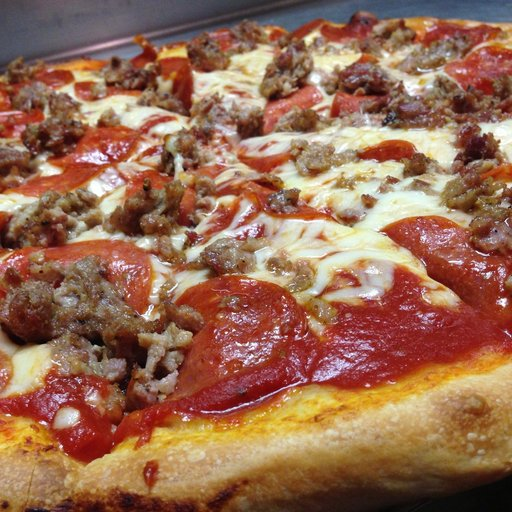

In [10]:
import random
from PIL import Image

# Set seed
# random.seed(42)

# 1. Get all image paths
image_path_list = list(image_path.glob("*/*/*.jpg"))

# 2. Pick a random image path
random_image_path = random.choice(image_path_list)

# 3. Get image class from path name (the image class is the name of the directory where the image is stored)
image_class = random_image_path.parent.stem

# 4. Open image
img = Image.open(random_image_path)

# 5. Print metadata
print(f"Random image path: {random_image_path}")
print(f"Image class: {image_class}")
print(f"Image height: {img.height}")
print(f"Image width: {img.width}")
img

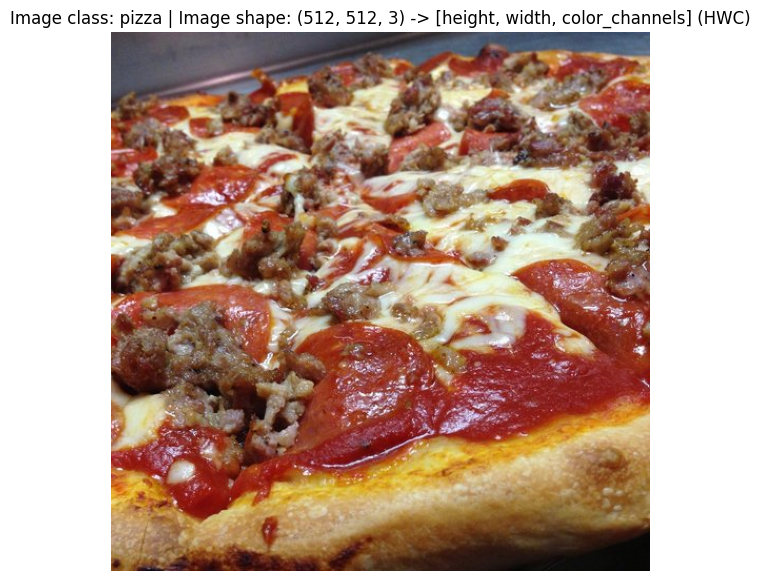

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Turn the image into an array
img_as_array = np.asarray(img)

# Plot the image with matplotlib
plt.figure(figsize=(10, 7))
plt.imshow(img_as_array)
plt.title(f"Image class: {image_class} | Image shape: {img_as_array.shape} -> [height, width, color_channels] (HWC)")
plt.axis(False);

array([[[ 76,  67,  72],
        [ 76,  67,  72],
        [ 75,  66,  71],
        ...,
        [ 72,  86, 121],
        [ 73,  87, 122],
        [ 72,  86, 121]],

       [[ 75,  66,  71],
        [ 74,  65,  70],
        [ 73,  64,  69],
        ...,
        [ 69,  84, 117],
        [ 70,  85, 118],
        [ 71,  86, 119]],

       [[ 73,  66,  73],
        [ 73,  66,  73],
        [ 72,  65,  72],
        ...,
        [ 67,  84, 112],
        [ 69,  86, 114],
        [ 70,  87, 115]],

       ...,

       [[142,  83,  39],
        [128,  71,  28],
        [117,  61,  24],
        ...,
        [  8,   8,   6],
        [  8,   8,   6],
        [  8,   8,   6]],

       [[136,  74,  27],
        [125,  64,  19],
        [119,  60,  16],
        ...,
        [  8,   8,   6],
        [  8,   8,   6],
        [  8,   8,   6]],

       [[149,  85,  37],
        [141,  79,  30],
        [138,  77,  32],
        ...,
        [  8,   8,   6],
        [  8,   8,   6],
        [  8,   8,   6]]], dtype=uint8)
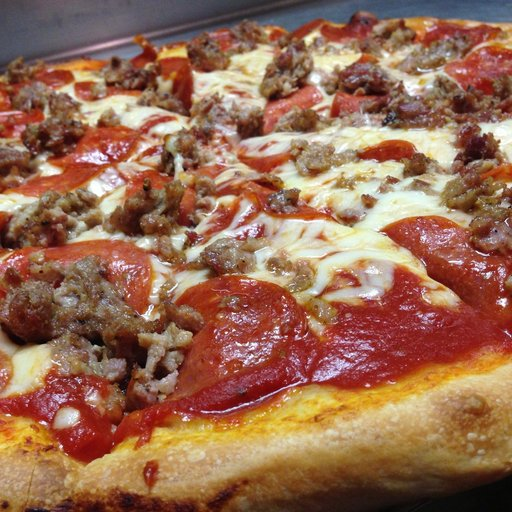

In [12]:
img_as_array

## 3. Transforming data

Before we can use our image data with PyTorch:
1. Turn your target data into tensors (in our case, numerical representation of our images).
2. Turn it into a `torch.utils.data.Dataset` and subsequently a `torch.utils.data.DataLoader`, we'll call these `Dataset` and `DataLoader`.



In [13]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

### 3.1 Transforming data with `torchvision.transforms`

Transforms help you get your images ready to be used with a model/perform data augmentation - https://pytorch.org/vision/stable/transforms.html

In [14]:
# Write a transform for image
data_transform = transforms.Compose([
  # Resize our images to 64x64
  transforms.Resize(size=(64, 64)),
  # Flip the images randomly on the horizontal
  transforms.RandomHorizontalFlip(p=0.5),
  # Turn the image into a torch.Tensor
  transforms.ToTensor()
])

In [15]:
data_transform(img).shape

torch.Size([3, 64, 64])

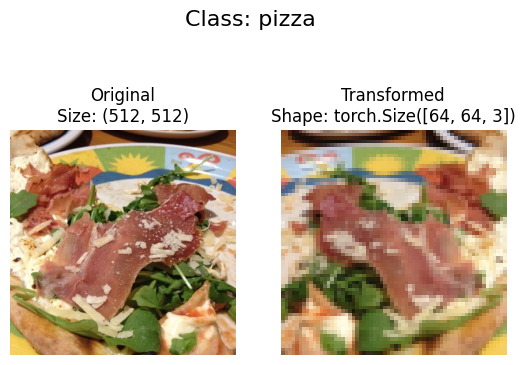

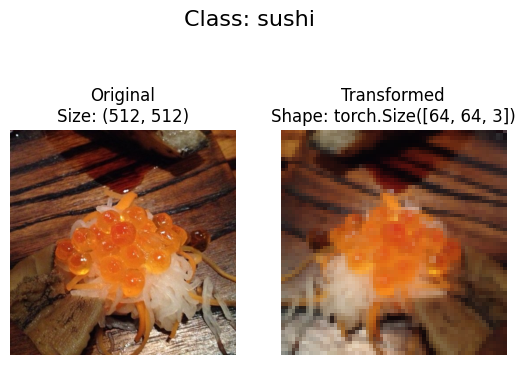

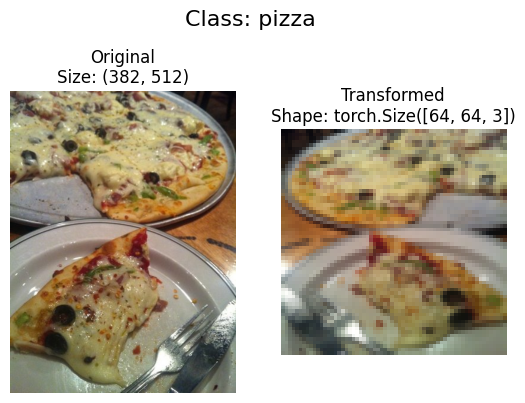

In [16]:
def plot_transformed_images(image_paths: list, transform, n=3, seed=None):
  """
  Selects random images from a path of images and loads/transforms
  them then plots the original vs the transformed version.
  """
  if seed:
    random.seed(seed)
  random_image_paths = random.sample(image_paths, k=n)
  for image_path in random_image_paths:
    with Image.open(image_path) as f:
      fig, ax = plt.subplots(nrows=1, ncols=2)
      ax[0].imshow(f)
      ax[0].set_title(f"Original\nSize: {f.size}")
      ax[0].axis(False)

      # Transform and plot target image
      transformed_image = transform(f).permute(1, 2, 0) # note we will need to change shape for matplotlib (C, H, W) -> (H, W, C)
      ax[1].imshow(transformed_image)
      ax[1].set_title(f"Transformed\nShape: {transformed_image.shape}")
      ax[1].axis("off")

      fig.suptitle(f"Class: {image_path.parent.stem}", fontsize=16)

plot_transformed_images(image_paths=image_path_list,
                        transform=data_transform,
                        n=3,
                        seed=None)

## 4. Option 1: Loading image data using `ImageFolder`

We can load image classification data using `torchvision.datasets.ImageFolder` - https://pytorch.org/vision/stable/generated/torchvision.datasets.ImageFolder.html#torchvision.datasets.ImageFolder

In [17]:
# Use ImageFolder to create dataset(s)
from torchvision import datasets
train_data = datasets.ImageFolder(root=train_dir,
                                  transform=data_transform, # a transform for the data
                                  target_transform=None) # a transform for the label/target

test_data = datasets.ImageFolder(root=test_dir,
                                 transform=data_transform)

train_data, test_data

(Dataset ImageFolder
     Number of datapoints: 225
     Root location: data/pizza_steak_sushi/train
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ),
 Dataset ImageFolder
     Number of datapoints: 75
     Root location: data/pizza_steak_sushi/test
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ))

In [18]:
train_dir, test_dir

(PosixPath('data/pizza_steak_sushi/train'),
 PosixPath('data/pizza_steak_sushi/test'))

In [19]:
# Get class names as list
class_names = train_data.classes
class_names

['pizza', 'steak', 'sushi']

In [20]:
# Get class names as dict
class_dict = train_data.class_to_idx
class_dict

{'pizza': 0, 'steak': 1, 'sushi': 2}

In [21]:
# Check the lengths of our dataset
len(train_data), len(test_data)

(225, 75)

In [22]:
train_data.samples[0]

('data/pizza_steak_sushi/train/pizza/1008844.jpg', 0)

In [23]:
# Index on the train_data Dataset to get a single image and label
img, label = train_data[0][0], train_data[0][1]
print(f"Image tensor:\n {img}")
print(f"Image shape: {img.shape}")
print(f"Image datatype: {img.dtype}")
print(f"Image label: {label}")
print(f"Label datatype: {type(label)}")

Image tensor:
 tensor([[[0.1137, 0.1020, 0.0980,  ..., 0.1255, 0.1216, 0.1176],
         [0.1059, 0.0980, 0.0980,  ..., 0.1294, 0.1294, 0.1294],
         [0.1020, 0.0980, 0.0941,  ..., 0.1333, 0.1333, 0.1333],
         ...,
         [0.1098, 0.1098, 0.1255,  ..., 0.1686, 0.1647, 0.1686],
         [0.0902, 0.0941, 0.1098,  ..., 0.1686, 0.1647, 0.1686],
         [0.0863, 0.0863, 0.0980,  ..., 0.1686, 0.1647, 0.1647]],

        [[0.0745, 0.0706, 0.0745,  ..., 0.0588, 0.0588, 0.0588],
         [0.0745, 0.0706, 0.0745,  ..., 0.0627, 0.0627, 0.0627],
         [0.0706, 0.0745, 0.0745,  ..., 0.0706, 0.0706, 0.0706],
         ...,
         [0.1255, 0.1333, 0.1373,  ..., 0.2510, 0.2392, 0.2392],
         [0.1098, 0.1176, 0.1255,  ..., 0.2510, 0.2392, 0.2314],
         [0.1020, 0.1059, 0.1137,  ..., 0.2431, 0.2353, 0.2275]],

        [[0.0941, 0.0902, 0.0902,  ..., 0.0157, 0.0196, 0.0196],
         [0.0902, 0.0863, 0.0902,  ..., 0.0196, 0.0157, 0.0196],
         [0.0902, 0.0902, 0.0902,  ..., 0.0

Original shape: torch.Size([3, 64, 64]) -> [color_channels, height, width]
Image permute: torch.Size([64, 64, 3]) -> [height, width, color_channels]


Text(0.5, 1.0, 'pizza')

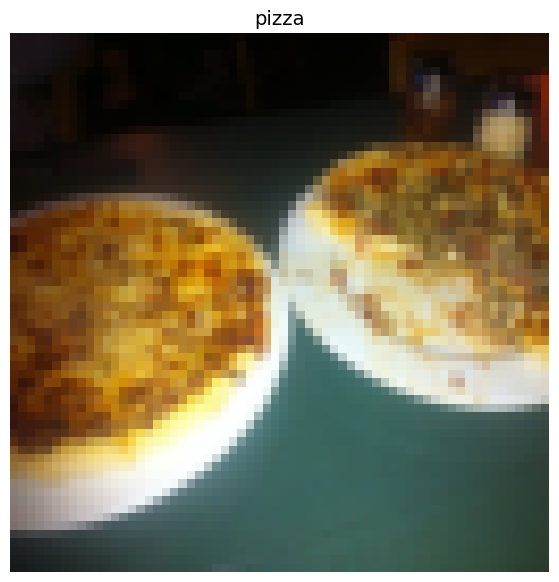

In [24]:
# Rearrange the order dimensions
img_permute = img.permute(1, 2, 0)

# Print out different shapes
print(f"Original shape: {img.shape} -> [color_channels, height, width]")
print(f"Image permute: {img_permute.shape} -> [height, width, color_channels]")

# Plot the image
plt.figure(figsize=(10, 7))
plt.imshow(img_permute)
plt.axis("off")
plt.title(class_names[label], fontsize=14)

### 4.1 Turn loaded images into `DataLoader`'s

A `DataLoader` is going to help us turn our `Dataset`'s into iterables and we can customise the `batch_size` so our model can see `batch_size` images at a time.

In [25]:
import os
os.cpu_count()

2

In [26]:
# Turn train and test datasets into DataLoader's
from torch.utils.data import DataLoader
BATCH_SIZE=1
train_dataloader = DataLoader(dataset=train_data,
                              batch_size=BATCH_SIZE,
                              num_workers=1,
                              shuffle=True)

test_dataloader = DataLoader(dataset=test_data,
                             batch_size=BATCH_SIZE,
                             num_workers=1,
                             shuffle=False)

train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x7c0d73b8ab40>,
 <torch.utils.data.dataloader.DataLoader at 0x7c0d73fd09b0>)

In [27]:
len(train_dataloader), len(test_dataloader)

(225, 75)

In [28]:
img, label = next(iter(train_dataloader))

# Batch size will now be 1, you can change the batch size if you like
print(f"Image shape: {img.shape} -> [batch_size, color_channels, height, width]")
print(f"Label shape: {label.shape}")

Image shape: torch.Size([1, 3, 64, 64]) -> [batch_size, color_channels, height, width]
Label shape: torch.Size([1])


## 5 Option 2: Loading Image Data with a Custom `Dataset`

1. Want to be able to load images from file
2. Want to be able to get class names from the Dataset
3. Want to be able to get classes as dictionary from the Dataset

Pros:
* Can create a `Dataset` out of almost anything
* Not limited to PyTorch pre-built `Dataset` functions

Cons:
* Even though you could create `Dataset` out of almost anything, it doesn't mean it will work...
* Using a custom `Dataset` often results in us writing more code, which could be prone to errors or performance issues

All custom datasets in PyTorch, often subclass - https://pytorch.org/docs/stable/data.html#torch.utils.data.Dataset


In [29]:
import os
import pathlib
import torch

from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms
from typing import Tuple, Dict, List

In [30]:
# Instance of torchvision.datasets.ImageFolder()
train_data.classes, train_data.class_to_idx

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

### 5.1 Creating a helper function to get class names

We want a function to:
1. Get the class names using `os.scandir()` to traverse a target directory (ideally the directory is in standard image classification format).
2. Raise an error if the class names aren't found (if this happens, there might be something wrong with the directory structure).
3. Turn the class names into a dict and a list and return them.

In [31]:
# Setup path for target directory
target_directory = train_dir
print(f"Target dir: {target_directory}")

# Get the class names from the target directory
class_names_found = sorted([entry.name for entry in list(os.scandir(target_directory))])
class_names_found

Target dir: data/pizza_steak_sushi/train


['pizza', 'steak', 'sushi']

In [32]:
list(os.scandir(target_directory))

[<DirEntry 'pizza'>, <DirEntry 'steak'>, <DirEntry 'sushi'>]

In [33]:
def find_classes(directory: str) -> Tuple[List[str], Dict[str, int]]:
  """Finds the class folder names in a target directory."""
  # 1. Get the class names by scanning the target directory
  classes = sorted(entry.name for entry in os.scandir(directory) if entry.is_dir())

  # 2. Raise an error if class names could not be found
  if not classes:
    raise FileNotFoundError(f"Couldn't find any classes in {directory}... please check file structure.")

  # 3. Create a dictionary of index labels (computers prefer numbers rather than strings as labels)
  class_to_idx = {class_name: i for i, class_name in enumerate(classes)}
  return classes, class_to_idx

In [34]:
find_classes(target_directory)

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

### 5.2 Create a custom `Dataset` to replicate `ImageFolder`

To create our own custom dataset, we want to:

1. Subclass `torch.utils.data.Dataset`
2. Init our subclass with a target directory (the directory we'd like to get data from) as well as a transform if we'd like to transform our data.
3. Create several attributes:
  * paths - paths of our images
  * transform - the transform we'd like to use
  * classes - a list of the target classes
  * class_to_idx - a dict of the target classes mapped to integer labels
4. Create a function to `load_images()`, this function will open an image
5. Overwrite the `__len()__` method to return the length of our dataset
6. Overwrite the `__getitem()__` method to return a given sample when passed an index

In [35]:
# 0. Write a custom dataset class
from torch.utils.data import Dataset

# 1. Subclass torch.utils.data.Dataset
class ImageFolderCustom(Dataset):
  # 2. Initialize our custom dataset
  def __init__(self,
               targ_dir: str,
               transform=None):
    # 3. Create class attributes
    # Get all of the image paths
    self.paths = list(pathlib.Path(targ_dir).glob("*/*.jpg"))
    # Setup transform
    self.transform = transform
    # Create classes and class_to_idx attributes
    self.classes, self.class_to_idx = find_classes(targ_dir)

  # 4. Create a function to load images
  def load_image(self, index: int) -> Image.Image:
    "Opens an image via a path and returns it."
    image_path = self.paths[index]
    return Image.open(image_path)

  # 5. Overwrite __len__()
  def __len__(self) -> int:
    "Returns the total number of samples."
    return len(self.paths)

  # 6. Overwrite __getitem__() method to return a particular sample
  def __getitem__(self, index: int) -> Tuple[torch.Tensor, int]:
    "Returns one sample of data, data and label (X, y)."
    img = self.load_image(index)
    class_name = self.paths[index].parent.name # expects path in format: data_folder/class_name/image.jpg
    class_idx = self.class_to_idx[class_name]

    # Transform if necessary
    if self.transform:
      return self.transform(img), class_idx # return data, label (X, y)
    else:
      return img, class_idx # return untransformed image and label

In [36]:
img, label = train_data[0]

In [37]:
img, label

(tensor([[[0.1176, 0.1216, 0.1255,  ..., 0.0980, 0.1020, 0.1137],
          [0.1294, 0.1294, 0.1294,  ..., 0.0980, 0.0980, 0.1059],
          [0.1333, 0.1333, 0.1333,  ..., 0.0941, 0.0980, 0.1020],
          ...,
          [0.1686, 0.1647, 0.1686,  ..., 0.1255, 0.1098, 0.1098],
          [0.1686, 0.1647, 0.1686,  ..., 0.1098, 0.0941, 0.0902],
          [0.1647, 0.1647, 0.1686,  ..., 0.0980, 0.0863, 0.0863]],
 
         [[0.0588, 0.0588, 0.0588,  ..., 0.0745, 0.0706, 0.0745],
          [0.0627, 0.0627, 0.0627,  ..., 0.0745, 0.0706, 0.0745],
          [0.0706, 0.0706, 0.0706,  ..., 0.0745, 0.0745, 0.0706],
          ...,
          [0.2392, 0.2392, 0.2510,  ..., 0.1373, 0.1333, 0.1255],
          [0.2314, 0.2392, 0.2510,  ..., 0.1255, 0.1176, 0.1098],
          [0.2275, 0.2353, 0.2431,  ..., 0.1137, 0.1059, 0.1020]],
 
         [[0.0196, 0.0196, 0.0157,  ..., 0.0902, 0.0902, 0.0941],
          [0.0196, 0.0157, 0.0196,  ..., 0.0902, 0.0863, 0.0902],
          [0.0196, 0.0157, 0.0157,  ...,

In [38]:
# Create a transform
from torchvision import transforms
train_transforms = transforms.Compose([
                                      transforms.Resize(size=(64, 64)),
                                      transforms.RandomHorizontalFlip(p=0.5),
                                      transforms.ToTensor()
])

test_transforms = transforms.Compose([
                                      transforms.Resize(size=(64, 64)),
                                      transforms.ToTensor()
])

In [39]:
# Test out ImageFolderCustom
train_data_custom = ImageFolderCustom(targ_dir=train_dir,
                                      transform=train_transforms)

test_data_custom = ImageFolderCustom(targ_dir=test_dir,
                                     transform=test_transforms)

In [40]:
train_data_custom, test_data_custom

(<__main__.ImageFolderCustom at 0x7c0d73b75f40>,
 <__main__.ImageFolderCustom at 0x7c0d73b8b980>)

In [41]:
len(train_data), len(train_data_custom)

(225, 225)

In [42]:
len(test_data), len(test_data_custom)

(75, 75)

In [43]:
train_data_custom.classes

['pizza', 'steak', 'sushi']

In [44]:
train_data_custom.class_to_idx

{'pizza': 0, 'steak': 1, 'sushi': 2}

In [45]:
# Check for equality between orginal Image Folder Datset and ImageFolderCustomeDatset
print(train_data_custom.classes==train_data.classes)
print(train_data_custom.class_to_idx==train_data.class_to_idx)

True
True


### 5.3 Create a function to display random images
1. Take in a `Dataset` and a number of other nn.parameters such as class names and how many images to visulize

In [46]:
from enum import nonmember
#1. Create a function take in a dataset
def display_random_images(datasets: torch.utils.data.Dataset,
                          classes: List[str] = None,
                          n: int = 10,
                          display_shape: bool = True,
                          seed: int = None):
  if n > 10:
    n= 10
    display_shape = False
    print(f"For display purposes, n shouldn't be larger than 10, setting to 10 and removing display_shape.")

  #3 Set the random seed for reprodusablity
  if seed:
    torch.manual_seed(seed)
  # Get the random sample indexes
  random_samples_idx = random.sample(range(len(datasets)), k=n)

  #5 Set up plot
  plt.figure(figsize=(16, 8))
  plt.subplots_adjust(hspace=0.5)

  #6Loop throung th eindexes ploat them with matplotlib
  for i, targe_sample in enumerate(random_samples_idx):
    target_image, target_label = datasets[targe_sample][0], datasets[targe_sample][1]

    #7. Adjust tensor dimensions for ploting
    target_image_adjust = target_image.permute(1, 2, 0)

    #plot the adjusted samples
    plt.subplot(1, n, i+1)
    plt.imshow(target_image_adjust)
    plt.axis("off")
    if classes:
      title = f"class: {classes[target_label]}"
      if display_shape:
        title = title + f"\nshape: {target_image_adjust.shape}"

    plt.title(title)


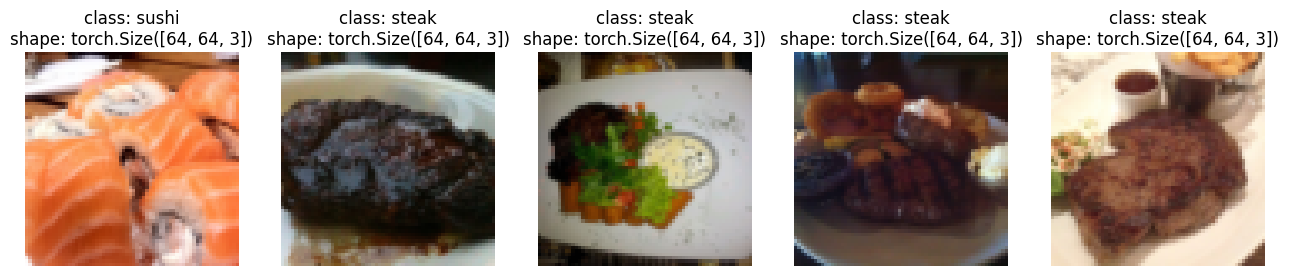

In [47]:
#Display the random images from the ImageFolder created Dataset
display_random_images(train_data,
                      n=5,
                      classes=class_names,
                      seed=None)

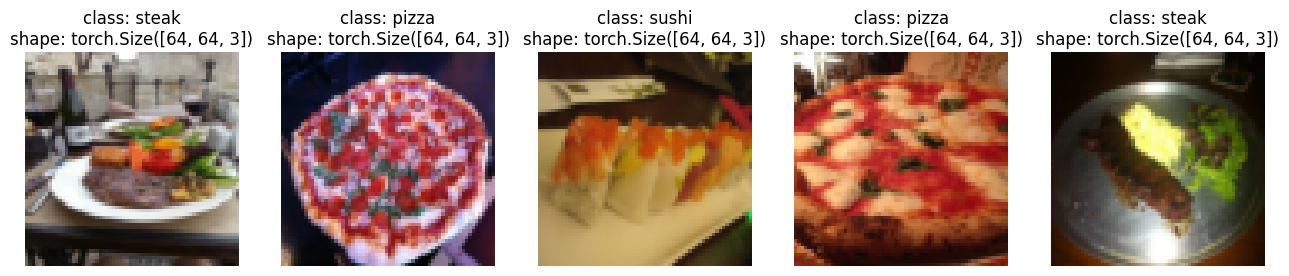

In [48]:
display_random_images(train_data_custom,
                      n=5,
                      classes=class_names,
                      seed=None)

In [49]:
from torch.utils.data import DataLoader
BATCH_SIZE = 32
NUM_WORKERS = os.cpu_count()
train_dataloader_custom = DataLoader(dataset=train_data_custom,
                                     batch_size=BATCH_SIZE,
                                     num_workers=NUM_WORKERS,
                                     shuffle=True)

test_dataloader_custom = DataLoader(dataset=test_data_custom,
                                    batch_size=BATCH_SIZE,
                                    num_workers=NUM_WORKERS,
                                    shuffle=False)
train_dataloader_custom, test_dataloader_custom

(<torch.utils.data.dataloader.DataLoader at 0x7c0d73ac6b10>,
 <torch.utils.data.dataloader.DataLoader at 0x7c0d73ac61b0>)

In [50]:
img_custom, label_custom = next(iter(train_dataloader_custom))
img_custom.shape, label_custom.shape

(torch.Size([32, 3, 64, 64]), torch.Size([32]))

In [51]:
from torchvision import transforms
trtain_transforms = transforms.Compose([
    transforms.Resize(size=(224, 224)),
    transforms.TrivialAugmentWide(num_magnitude_bins=31),
    transforms.ToTensor()
])

test_transforms = transforms.Compose([
    transforms.Resize(size=(224, 224)),
    transforms.ToTensor()
])


In [52]:
#Get all the image path
image_path_list = list(image_path.glob("*/*/*.jpg"))
image_path_list[:10]

[PosixPath('data/pizza_steak_sushi/train/pizza/765799.jpg'),
 PosixPath('data/pizza_steak_sushi/train/pizza/1572608.jpg'),
 PosixPath('data/pizza_steak_sushi/train/pizza/29417.jpg'),
 PosixPath('data/pizza_steak_sushi/train/pizza/1633289.jpg'),
 PosixPath('data/pizza_steak_sushi/train/pizza/1649276.jpg'),
 PosixPath('data/pizza_steak_sushi/train/pizza/3699992.jpg'),
 PosixPath('data/pizza_steak_sushi/train/pizza/1660415.jpg'),
 PosixPath('data/pizza_steak_sushi/train/pizza/1524655.jpg'),
 PosixPath('data/pizza_steak_sushi/train/pizza/3269634.jpg'),
 PosixPath('data/pizza_steak_sushi/train/pizza/2569760.jpg')]

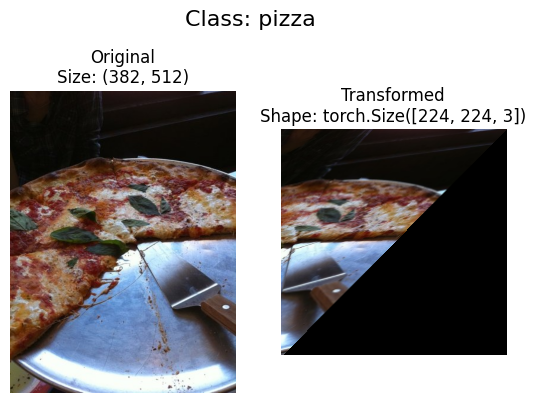

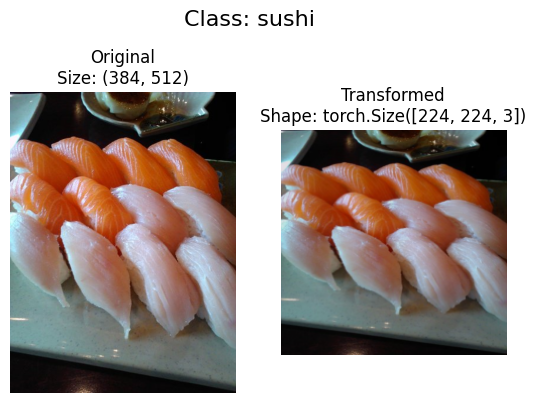

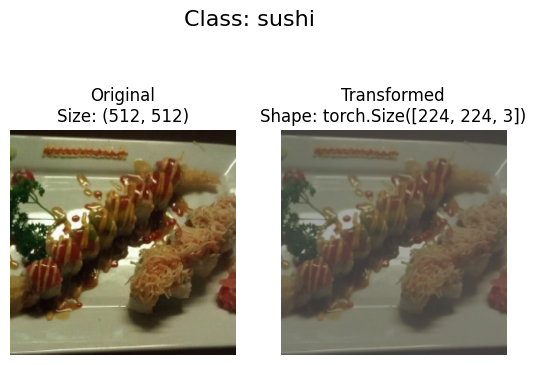

In [53]:
plot_transformed_images(
    image_paths=image_path_list,
    transform=trtain_transforms,
    n=3,
    seed=None
)

#7 MOdel 0: TinyVGG without data Augmenatation

### 7. Creating tranforms and loading data for model 0

In [54]:
simple_transfrom = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

In [55]:
from IPython.testing import test
from logging import root
from torchvision import datasets
train_data_simple =  datasets.ImageFolder(root=train_dir,
                                          transform=simple_transfrom)
test_data_simple = datasets.ImageFolder(root=test_dir,
                                              transform=simple_transfrom)
# 2. Turn datasets into dataloaders
import os
from torch.utils.data import DataLoader
BATCH_SIZE=32
NUM_WORKERS = os.cpu_count()

train_dataloader_simple = DataLoader(dataset=train_data_simple,
                                     batch_size=BATCH_SIZE,
                                     num_workers=NUM_WORKERS,
                                     shuffle=True)
test_dataloader_simple = DataLoader(dataset=test_data_simple,
                                    batch_size=BATCH_SIZE,
                                    num_workers=NUM_WORKERS,
                                    shuffle=False)

###7.2 TinyVGG model class

In [56]:
class TinyVGG(nn.Module):
  def __init__(self,
               input_shape : int,
               hidden_units: int,
               output_shape :int) -> None:
    super().__init__()
    self.conv_block_1 = nn.Sequential(
        nn.Conv2d(in_channels=input_shape,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=0),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=0),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2,
                     stride=2)
    )
    self.conv_block_2 = nn.Sequential(
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=0),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=0),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2,
                     stride=2)
    )
    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=hidden_units*13*13,
                  out_features=output_shape)
    )
  def forward(self, x):
    x = self.conv_block_1(x)
    #print(x.shape)
    x = self.conv_block_2(x)
    #print(x.shape)
    x = self.classifier(x)
    #print(x.shape)
    return x

In [57]:
torch.manual_seed(42)
model_0 = TinyVGG(input_shape=3,
                  hidden_units=10,
                  output_shape=len(class_names)).to(device)
model_0

TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1690, out_features=3, bias=True)
  )
)

### 7.3 Try s forward passon single image(to test the model)


In [58]:
image_batch, label_batch = next(iter(train_dataloader_simple))
image_batch.shape, label_batch.shape

(torch.Size([32, 3, 64, 64]), torch.Size([32]))

In [59]:
#Try a forward pass
model_0(image_batch.to(device))

tensor([[ 2.0795e-02, -1.9510e-03,  9.5212e-03],
        [ 1.8440e-02,  2.4669e-03,  6.6609e-03],
        [ 1.7695e-02,  1.0282e-03,  9.4975e-03],
        [ 2.4446e-02, -3.3489e-03,  9.5877e-03],
        [ 1.9939e-02,  6.9129e-04,  1.0778e-02],
        [ 2.1281e-02,  2.0434e-03,  5.0046e-03],
        [ 2.0996e-02,  1.6417e-04,  1.2481e-02],
        [ 2.1566e-02, -1.9607e-03,  9.7175e-03],
        [ 2.4500e-02, -4.7904e-03,  8.5394e-03],
        [ 2.0239e-02, -4.7980e-04,  1.0907e-02],
        [ 2.2219e-02, -4.1815e-04,  9.8173e-03],
        [ 2.2318e-02, -2.1642e-03,  9.4428e-03],
        [ 2.1851e-02, -3.7225e-03,  8.3784e-03],
        [ 2.2881e-02, -1.7559e-03,  1.0299e-02],
        [ 2.1635e-02, -4.3994e-03,  9.4990e-03],
        [ 2.2101e-02, -4.1469e-03,  9.3904e-03],
        [ 2.1226e-02, -4.4215e-03,  1.1476e-02],
        [ 2.1698e-02, -2.7458e-03,  8.4966e-03],
        [ 1.9974e-02, -3.2317e-07,  8.4496e-03],
        [ 1.8308e-02,  1.6378e-03,  8.5491e-03],
        [ 2.0768e-02

In [60]:
try:
  import torchinfo
except:
  !pip install torchinfo
  import torchinfo
from torchinfo import summary
summary(model=model_0, input_size=[1, 3, 64, 64])

Layer (type:depth-idx)                   Output Shape              Param #
TinyVGG                                  [1, 3]                    --
├─Sequential: 1-1                        [1, 10, 30, 30]           --
│    └─Conv2d: 2-1                       [1, 10, 62, 62]           280
│    └─ReLU: 2-2                         [1, 10, 62, 62]           --
│    └─Conv2d: 2-3                       [1, 10, 60, 60]           910
│    └─ReLU: 2-4                         [1, 10, 60, 60]           --
│    └─MaxPool2d: 2-5                    [1, 10, 30, 30]           --
├─Sequential: 1-2                        [1, 10, 13, 13]           --
│    └─Conv2d: 2-6                       [1, 10, 28, 28]           910
│    └─ReLU: 2-7                         [1, 10, 28, 28]           --
│    └─Conv2d: 2-8                       [1, 10, 26, 26]           910
│    └─ReLU: 2-9                         [1, 10, 26, 26]           --
│    └─MaxPool2d: 2-10                   [1, 10, 13, 13]           --
├─Sequentia

## 7.5 Create train and test loops functions


In [61]:
def train_step(model: torch.nn.Module,
               dataloader : torch.utils.data.DataLoader,
               loss_fn : torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               device=device):
  model.train()

  train_loss, train_acc = 0, 0 # Initialize train_loss and train_acc

  for batch, (X, y) in enumerate(dataloader):
    X, y = X.to(device), y.to(device)

    y_pred = model(X)

    loss = loss_fn(y_pred, y)
    train_loss += loss.item()

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
    train_acc += (y_pred_class == y).sum().item()/len(y_pred)

  train_loss = train_loss / len(dataloader)
  train_acc = train_acc / len(dataloader)
  return train_loss, train_acc

In [62]:
#Create test step function
def test_step(model:torch.nn.Module,
              dataloader : torch.utils.data.DataLoader,
              loss_fn : torch.nn.Module,
              device=device):
  model.eval()


  test_loss, test_acc = 0, 0

  #Turn on Inference mod
  with torch.inference_mode():
    for batach, (X, y) in enumerate(dataloader):
      X, y = X.to(device), y.to(device)

      test_pred_logits = model(X)

      loss = loss_fn(test_pred_logits, y)
      test_loss += loss.item()

      test_pred_labels = test_pred_logits.argmax(dim=1)
      test_acc += ((test_pred_labels == y).sum().item()/len(test_pred_labels))

  test_loss = test_loss / len(dataloader)
  test_acc = test_acc / len(dataloader)
  return test_loss, test_acc


### 7.6 Creating a `train()` function to combine `train_step` and `test_step`

In [63]:
from tqdm.auto import tqdm
def fit(model: torch.nn.Module,
        train_dataloader: torch.utils.data.DataLoader,
        test_dataloader:torch.utils.data.DataLoader,
        optimizer:torch.optim.Optimizer,
        loss_fn:torch.nn.Module = nn.CrossEntropyLoss(),
        epochs:int=5,
        device=device):
  results = {"train_loss": [],
             "test_loss": [],
             "train_acc": [],
             "test_acc": []}
  for epoch in tqdm(range(epochs)):
    train_loss, train_acc = train_step(model=model,
                                       dataloader=train_dataloader,
                                       loss_fn=loss_fn,
                                       optimizer=optimizer,
                                       device=device)
    test_loss, test_acc = test_step(model,
                                    dataloader=test_dataloader,
                                    loss_fn=loss_fn,
                                    device=device)
    print(f"Epoch: {epoch} | Train loss: {train_loss:.4f} | Test Loss: {test_loss:.4f} | Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f}")

    results["train_loss"].append(train_loss)
    results["test_loss"].append(test_loss)
    results["train_acc"].append(train_acc)
    results["test_acc"].append(test_acc)

  return results


  ### 7.7 Train and evaluate model 0

In [80]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

#Set number of eppochs
NUM_EPOCHS = 5
# Recreate an instance of TinyVGG
model_0 = TinyVGG(input_shape=3,
                  hidden_units=10,
                  output_shape = len(train_data.classes)).to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_0.parameters(),
                             lr=0.001)
#Strat the timer
from timeit import default_timer as timer
start_time = timer()

#Train model_0
model_0_results = fit(model=model_0,
                      train_dataloader=train_dataloader_simple,
                      test_dataloader=test_dataloader_simple,
                      optimizer=optimizer,
                      loss_fn=loss_fn,
                      epochs=NUM_EPOCHS)

#End the timer and print out how long it took
end_time = timer()
print(f"Total training time: {end_time-start_time:.3f} seconds")

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 0 | Train loss: 1.1063 | Test Loss: 1.0983 | Train Acc: 0.3047 | Test Acc: 0.3011
Epoch: 1 | Train loss: 1.0998 | Test Loss: 1.0697 | Train Acc: 0.3281 | Test Acc: 0.5417
Epoch: 2 | Train loss: 1.0869 | Test Loss: 1.0809 | Train Acc: 0.4883 | Test Acc: 0.4924
Epoch: 3 | Train loss: 1.0846 | Test Loss: 1.0606 | Train Acc: 0.3984 | Test Acc: 0.5729
Epoch: 4 | Train loss: 1.0662 | Test Loss: 1.0657 | Train Acc: 0.4219 | Test Acc: 0.5644
Total training time: 4.503 seconds


### 7.8 Plot the loss curves of oure model_0

In [81]:
# Get the model_) results keys
model_0_results.keys()

dict_keys(['train_loss', 'test_loss', 'train_acc', 'test_acc'])

In [82]:
from math import e
def plot_loss_curves(results: Dict[str, List[float]]):
  """Plot training curves of a results dictionary.

  Args:
      results (dict): dictionary
  """
  loss = results["train_loss"]
  test_loss = results["test_loss"]
  # Get the accuracy values of the results dictionary(training and test)
  accuracy = results["train_acc"]
  test_accuracy = results["test_acc"]
  epochs = range(len(results["train_loss"]))

  #setup the plot
  plt.figure(figsize=(15, 7))

  #Plot the loss
  plt.subplot(1, 2, 1)
  plt.plot(epochs, loss, label="train_loss")
  plt.plot(epochs, test_loss, label="test_loss")
  plt.title("Loss")
  plt.xlabel("Epochs")
  plt.legend()

  #Plot the accuracy
  plt.subplot(1, 2, 2)
  plt.plot(epochs, accuracy, label="train_accuracy")
  plt.plot(epochs, test_accuracy, label="test_accuracy")
  plt.title("Accuracy")
  plt.xlabel("Epochs")
  plt.legend()
  plt.show();



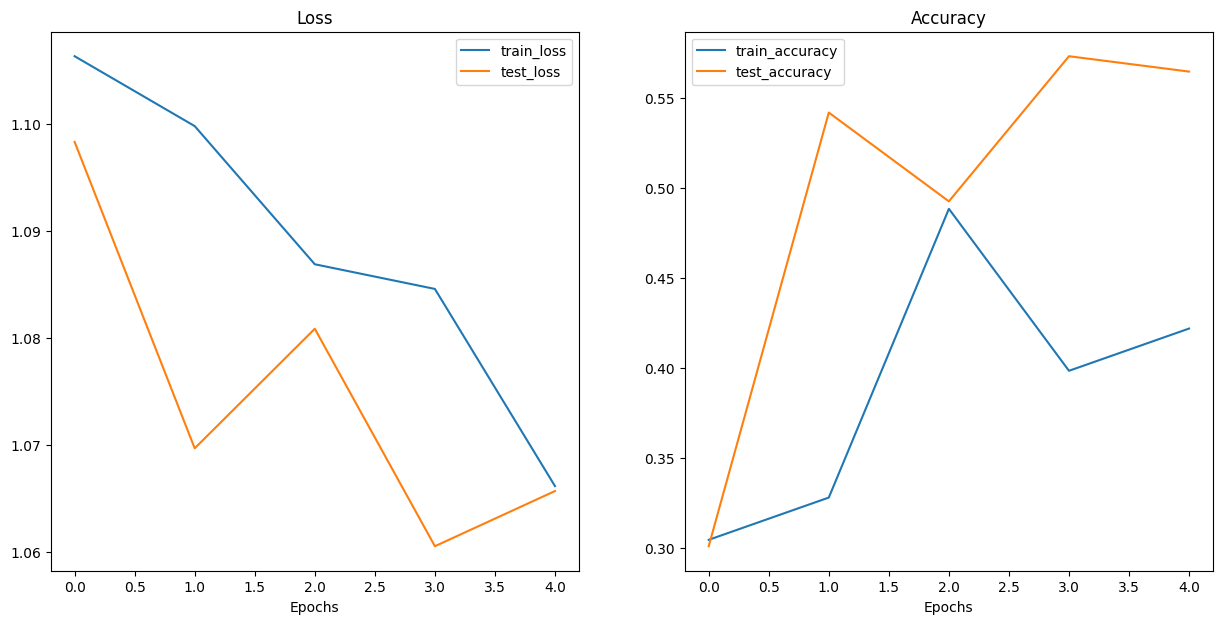

In [83]:
plot_loss_curves(model_0_results)

## 8. What should an ideal loss curve look like?


## 9. Model 1: TinuVGG with Data Augmentation

### 9.1 reate a transform wuth data augmentation

In [84]:
from torchvision import transforms
train_transforms_trivial = transforms.Compose([
    transforms.Resize(size=(64, 64)),
    transforms.TrivialAugmentWide(num_magnitude_bins=31),
    transforms.ToTensor()
])

test_transforms_simple = transforms.Compose([
    transforms.Resize(size=(64, 64)),
    transforms.ToTensor()
])


### 9.2 Create train and test `Datasets` and `DataLoader` with data augmentation

In [85]:
# Turn image folder into Datsets
import torchvision
from torchvision import datasets
train_data_augmented = datasets.ImageFolder(root=train_dir,
                                            transform=train_transforms_trivial,
                                            target_transform=None)
test_data_simple = datasets.ImageFolder(root=test_dir,
                                           transform=test_transforms_simple)

In [86]:
# Turn our datasets into dataloaders
import os
BATCH_SIZE = 32
NUM_WORKERS = os.cpu_count()
torch.manual_seed(42)
train_dataloader_augmented = DataLoader(dataset=train_data_augmented,
                                         batch_size=BATCH_SIZE,
                                         num_workers=NUM_WORKERS,
                                         shuffle=True)
test_dataloader_simple = DataLoader(dataset=test_data_simple,
                                    batch_size=BATCH_SIZE,
                                    num_workers=NUM_WORKERS,
                                    shuffle=False)

###9.3 Construct and train model_1

In [87]:
# CReate model_1 and sent to the target device
torch.manual_seed(42)
model_1 = TinyVGG(input_shape=3,
                  hidden_units=10,
                  output_shape=len(train_data_augmented)).to(device)

model_1

TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1690, out_features=225, bias=True)
  )
)

In [88]:
#set the random seed
torch.manual_seed(42)
torch.cuda.manual_seed(42)


NUM_EPOCHS = 5
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_1.parameters(),
                             lr=0.001)
#Strat the timer
start_time = timer()

#Train model_0
model_1_results = fit(model=model_1,
                      train_dataloader=train_dataloader_augmented,
                      test_dataloader=test_dataloader_simple,
                      optimizer=optimizer,
                      loss_fn=loss_fn,
                      epochs=NUM_EPOCHS,
                      device=device)
end_time = timer()
print(f"Total training time: {end_time-start_time:.3f} seconds")

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 0 | Train loss: 4.8074 | Test Loss: 3.6115 | Train Acc: 0.3945 | Test Acc: 0.2604
Epoch: 1 | Train loss: 2.2361 | Test Loss: 1.1481 | Train Acc: 0.4258 | Test Acc: 0.2604
Epoch: 2 | Train loss: 1.1498 | Test Loss: 1.0949 | Train Acc: 0.3008 | Test Acc: 0.3011
Epoch: 3 | Train loss: 1.1205 | Test Loss: 1.1343 | Train Acc: 0.3125 | Test Acc: 0.2585
Epoch: 4 | Train loss: 1.1320 | Test Loss: 1.0931 | Train Acc: 0.3281 | Test Acc: 0.2604
Total training time: 4.650 seconds


In [89]:
model_1_results

{'train_loss': [4.807353854179382,
  2.2361250072717667,
  1.149804100394249,
  1.1205362677574158,
  1.1319961696863174],
 'test_loss': [3.611513296763102,
  1.1480510433514912,
  1.094865083694458,
  1.1342506408691406,
  1.0930542548497517],
 'train_acc': [0.39453125, 0.42578125, 0.30078125, 0.3125, 0.328125],
 'test_acc': [0.2604166666666667,
  0.2604166666666667,
  0.30113636363636365,
  0.2585227272727273,
  0.2604166666666667]}

### 9.4 plot the loss curve of model_1

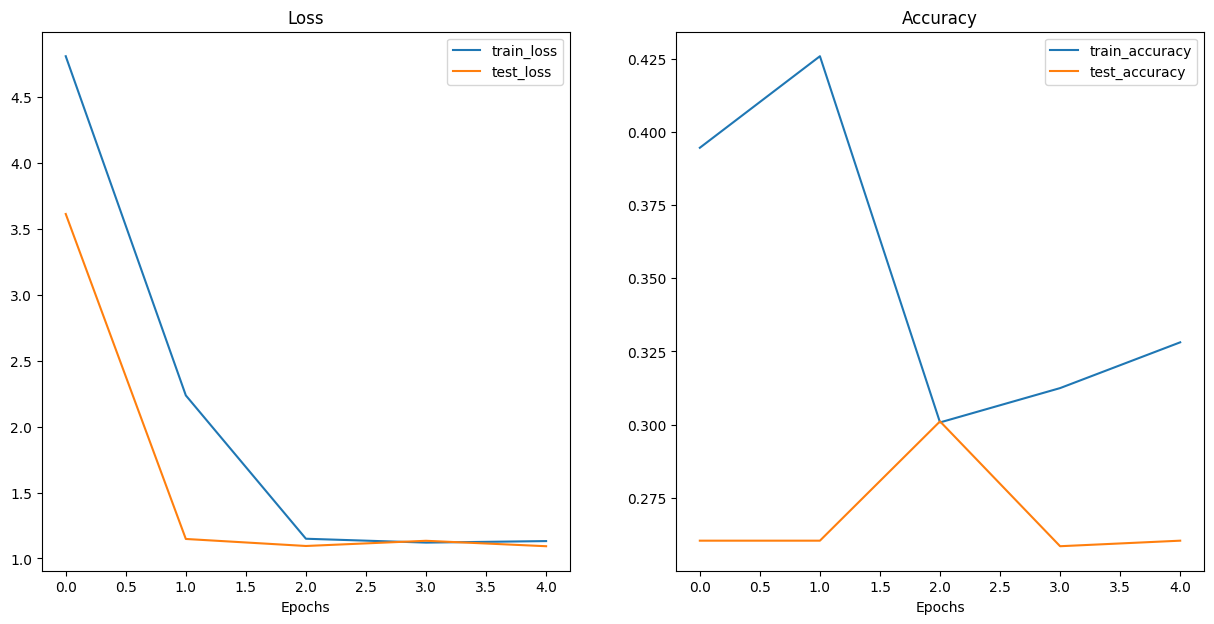

In [90]:
plot_loss_curves(model_1_results)

## 10 Compare model results


In [91]:
import pandas as pd

model_0_df = pd.DataFrame(model_0_results)
model_1_df = pd.DataFrame(model_1_results)
model_0_df

,train_loss,test_loss,train_acc,test_acc
0,1.106320,1.098320,0.304688,0.301136
1,1.099793,1.069700,0.328125,0.541667
2,1.086891,1.080868,0.488281,0.492424
3,1.084586,1.060558,0.398438,0.572917
4,1.066172,1.065710,0.421875,0.564394


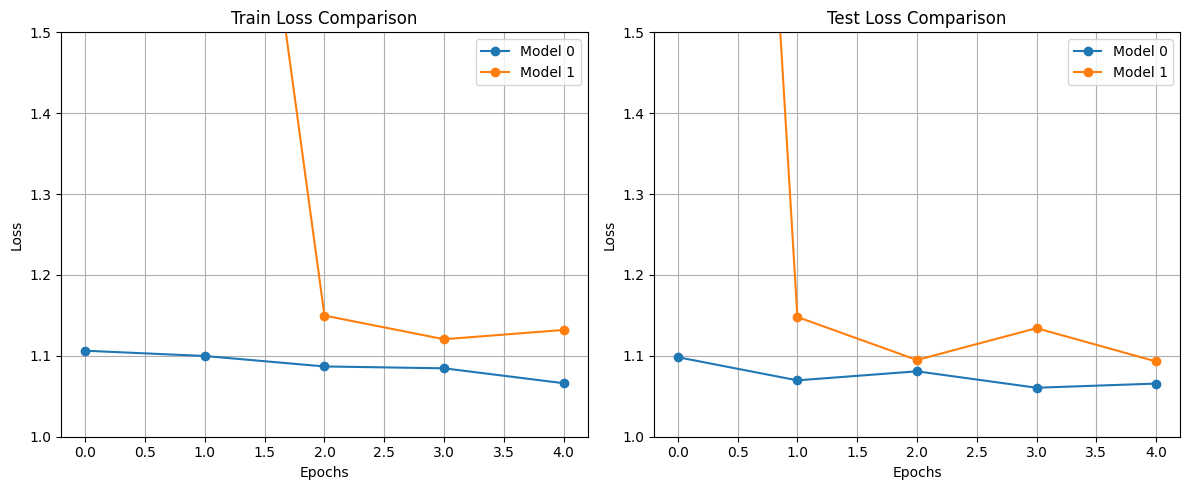

In [93]:
import matplotlib.pyplot as plt

# Epochs
epochs = range(len(model_0_df))

plt.figure(figsize=(12, 5))

# -------- Train Loss --------
plt.subplot(1, 2, 1)
plt.plot(epochs, model_0_df["train_loss"], marker='o', label="Model 0")
plt.plot(epochs, model_1_df["train_loss"], marker='o', label="Model 1")

plt.title("Train Loss Comparison")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# Zoom to see differences clearly
plt.ylim(1.0, 1.5)

# -------- Test Loss --------
plt.subplot(1, 2, 2)
plt.plot(epochs, model_0_df["test_loss"], marker='o', label="Model 0")
plt.plot(epochs, model_1_df["test_loss"], marker='o', label="Model 1")

plt.title("Test Loss Comparison")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# Optional zoom
plt.ylim(1.0, 1.5)

plt.tight_layout()
plt.show()

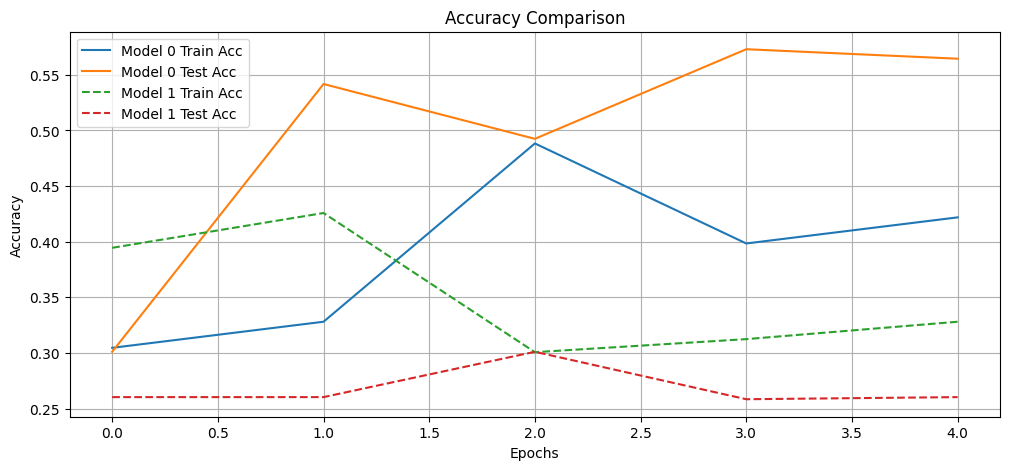

In [94]:
plt.figure(figsize=(12, 5))

plt.plot(epochs, model_0_df["train_acc"], label="Model 0 Train Acc")
plt.plot(epochs, model_0_df["test_acc"], label="Model 0 Test Acc")

plt.plot(epochs, model_1_df["train_acc"], '--', label="Model 1 Train Acc")
plt.plot(epochs, model_1_df["test_acc"], '--', label="Model 1 Test Acc")

plt.title("Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

 ## 12 Making a prediction in on a custome image

In [112]:
import requests

custome_image_path = data_path / "01_pizza_not_pizza.jpeg"

image_url = "https://hips.hearstapps.com/hmg-prod/images/classic-cheese-pizza-recipe-2-64429a0cb408b.jpg?crop=0.8888888888888888xw:1xh;0,0"

headers = {
    "User-Agent": "Mozilla/5.0"
}

if not custome_image_path.is_file():
    image_request = requests.get(image_url, headers=headers)

    if image_request.status_code == 200:
        with open(custome_image_path, "wb") as f:
            print(f"Downloading image from {image_url}")
            f.write(image_request.content)
    else:
        print("Failed to download image:", image_request.status_code)
else:
    print(f"{custome_image_path} already exists")

### 11.1 Loading in a custome image withPyTorch



In [114]:
import torchvision
custom_image_uint8 = torchvision.io.read_image(str(custome_image_path))
print(f"Custome image tensor:\n{custom_image_uint8}")
print(f"Custome image shape:\n{custom_image_uint8.shape}")
print(f"Custome image dtype:\n{custom_image_uint8.dtype}")

Custome image tensor:
tensor([[[202, 204, 209,  ..., 122, 127, 124],
         [205, 206, 209,  ..., 117, 120, 119],
         [209, 209, 211,  ..., 111, 116, 115],
         ...,
         [214, 222, 233,  ..., 162, 177, 181],
         [184, 186, 190,  ..., 153, 165, 171],
         [152, 148, 146,  ..., 145, 150, 170]],

        [[ 71,  78,  86,  ..., 105, 106, 103],
         [ 74,  80,  89,  ..., 101, 103,  99],
         [ 80,  84,  92,  ...,  97, 100, 100],
         ...,
         [184, 192, 200,  ..., 197, 212, 216],
         [148, 150, 154,  ..., 188, 200, 206],
         [113, 109, 107,  ..., 181, 185, 205]],

        [[ 77,  82,  89,  ...,  79,  77,  72],
         [ 80,  84,  91,  ...,  78,  77,  72],
         [ 85,  88,  94,  ...,  84,  84,  81],
         ...,
         [150, 158, 167,  ..., 199, 216, 220],
         [126, 128, 132,  ..., 190, 204, 210],
         [ 96,  92,  92,  ..., 181, 189, 209]]], dtype=torch.uint8)
Custome image shape:
torch.Size([3, 800, 1422])
Custome image dty

### 11.2 Making a prediction image with a trained PyTorch Model


In [116]:
model_1.eval()
with torch.inference_mode():
    custom_image_pred = model_1(custom_image_uint8.to(device))



RuntimeError: Input type (unsigned char) and bias type (float) should be the same

In [118]:
#Load the custome image and cover to torch.float32
custom_image = torchvision.io.read_image(str(custome_image_path)).type(torch.float32)
custom_image

tensor([[[202., 204., 209.,  ..., 122., 127., 124.],
         [205., 206., 209.,  ..., 117., 120., 119.],
         [209., 209., 211.,  ..., 111., 116., 115.],
         ...,
         [214., 222., 233.,  ..., 162., 177., 181.],
         [184., 186., 190.,  ..., 153., 165., 171.],
         [152., 148., 146.,  ..., 145., 150., 170.]],

        [[ 71.,  78.,  86.,  ..., 105., 106., 103.],
         [ 74.,  80.,  89.,  ..., 101., 103.,  99.],
         [ 80.,  84.,  92.,  ...,  97., 100., 100.],
         ...,
         [184., 192., 200.,  ..., 197., 212., 216.],
         [148., 150., 154.,  ..., 188., 200., 206.],
         [113., 109., 107.,  ..., 181., 185., 205.]],

        [[ 77.,  82.,  89.,  ...,  79.,  77.,  72.],
         [ 80.,  84.,  91.,  ...,  78.,  77.,  72.],
         [ 85.,  88.,  94.,  ...,  84.,  84.,  81.],
         ...,
         [150., 158., 167.,  ..., 199., 216., 220.],
         [126., 128., 132.,  ..., 190., 204., 210.],
         [ 96.,  92.,  92.,  ..., 181., 189., 209.]]]

In [120]:
model_1.eval()
with torch.inference_mode():
    custom_image_pred = model_1(custom_image.to(device))

RuntimeError: mat1 and mat2 shapes cannot be multiplied (10x69344 and 1690x225)

In [121]:
custom_image.shape

torch.Size([3, 800, 1422])

In [122]:
custom_image = torchvision.io.read_image(str(custome_image_path)).type(torch.float32) / 255.
custom_image

tensor([[[0.7922, 0.8000, 0.8196,  ..., 0.4784, 0.4980, 0.4863],
         [0.8039, 0.8078, 0.8196,  ..., 0.4588, 0.4706, 0.4667],
         [0.8196, 0.8196, 0.8275,  ..., 0.4353, 0.4549, 0.4510],
         ...,
         [0.8392, 0.8706, 0.9137,  ..., 0.6353, 0.6941, 0.7098],
         [0.7216, 0.7294, 0.7451,  ..., 0.6000, 0.6471, 0.6706],
         [0.5961, 0.5804, 0.5725,  ..., 0.5686, 0.5882, 0.6667]],

        [[0.2784, 0.3059, 0.3373,  ..., 0.4118, 0.4157, 0.4039],
         [0.2902, 0.3137, 0.3490,  ..., 0.3961, 0.4039, 0.3882],
         [0.3137, 0.3294, 0.3608,  ..., 0.3804, 0.3922, 0.3922],
         ...,
         [0.7216, 0.7529, 0.7843,  ..., 0.7725, 0.8314, 0.8471],
         [0.5804, 0.5882, 0.6039,  ..., 0.7373, 0.7843, 0.8078],
         [0.4431, 0.4275, 0.4196,  ..., 0.7098, 0.7255, 0.8039]],

        [[0.3020, 0.3216, 0.3490,  ..., 0.3098, 0.3020, 0.2824],
         [0.3137, 0.3294, 0.3569,  ..., 0.3059, 0.3020, 0.2824],
         [0.3333, 0.3451, 0.3686,  ..., 0.3294, 0.3294, 0.

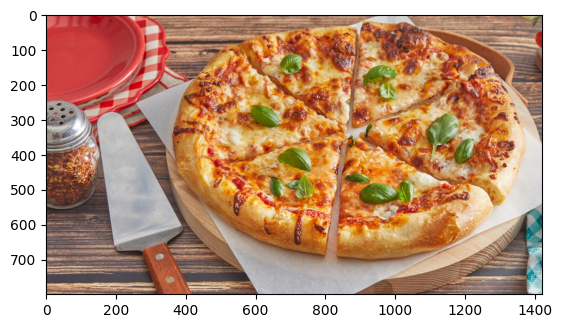

In [123]:
plt.imshow(custom_image.permute(1, 2, 0))

In [127]:
# Create transform pipeline to resize the image
custom_image_transform = transforms.Compose([
    transforms.Resize(size=(64, 64))
])

In [128]:
#Transform our target image
custom_image_transformed = custom_image_transform(custom_image)
#Printout the shape
print(f"Custom image shape: {custom_image_transformed.shape}")
print(f"orginal image shape: {custom_image.shape}")

Custom image shape: torch.Size([3, 64, 64])
orginal image shape: torch.Size([3, 800, 1422])


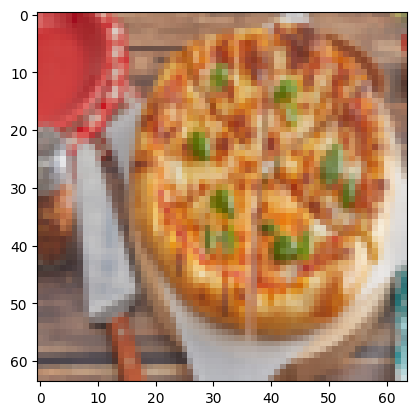

In [129]:
plt.imshow(custom_image_transformed.permute(1, 2, 0))

In [133]:
#THis will error no batch size
model_1.eval()
with torch.inference_mode():
    custom_image_pred = model_1(custom_image_transformed.to(device))

RuntimeError: mat1 and mat2 shapes cannot be multiplied (10x169 and 1690x225)

In [134]:
custom_image_transformed.shape

torch.Size([3, 64, 64])

In [136]:
#This should work? (add a batch size...)
model_1.eval()
with torch.inference_mode():
    custom_image_pred = model_1(custom_image_transformed.unsqueeze(0).to(device))
custom_image_pred

tensor([[ 15.4758,  14.1968,  15.0843, -20.0004, -20.0068, -20.1284, -19.9824,
         -19.5613, -19.9488, -20.7012, -20.2867, -19.3715, -20.0096, -20.2267,
         -19.6311, -20.1205, -20.1080, -20.2124, -19.2924, -19.9697, -19.2690,
         -20.2217, -19.8944, -20.1089, -20.4106, -20.1004, -20.4095, -19.8712,
         -20.0175, -20.1063, -20.1645, -20.5855, -19.4783, -20.2529, -19.6757,
         -19.7337, -19.6979, -19.8560, -19.9542, -19.8259, -20.3550, -20.0119,
         -20.5612, -19.7612, -20.3287, -19.9663, -20.8301, -19.4650, -19.6167,
         -19.9170, -20.6602, -20.2210, -20.2035, -20.3689, -19.4419, -19.4745,
         -20.7892, -19.8514, -20.5847, -20.4192, -19.4893, -20.4675, -20.3477,
         -20.1426, -20.1924, -20.5120, -20.2648, -20.2607, -20.3023, -19.5459,
         -20.1230, -20.0321, -19.7962, -19.4470, -20.3861, -20.2231, -20.6397,
         -19.8623, -20.9474, -20.6878, -19.7304, -19.7575, -19.9140, -20.3616,
         -20.2772, -19.8801, -19.6287, -19.6055, -20

In [137]:
# Covert logits -> prediction probablities
custome_image_pred_probs = torch.softmax(custom_image_pred, dim=1)
custome_image_pred_probs

tensor([[5.1168e-01, 1.4241e-01, 3.4591e-01, 2.0038e-16, 1.9911e-16, 1.7631e-16,
         2.0404e-16, 3.1086e-16, 2.1100e-16, 9.9434e-17, 1.5050e-16, 3.7586e-16,
         1.9855e-16, 1.5981e-16, 2.8991e-16, 1.7772e-16, 1.7994e-16, 1.6212e-16,
         4.0677e-16, 2.0664e-16, 4.1639e-16, 1.6061e-16, 2.2279e-16, 1.7979e-16,
         1.3296e-16, 1.8133e-16, 1.3311e-16, 2.2803e-16, 1.9699e-16, 1.8025e-16,
         1.7006e-16, 1.1162e-16, 3.3777e-16, 1.5567e-16, 2.7727e-16, 2.6165e-16,
         2.7117e-16, 2.3153e-16, 2.0986e-16, 2.3859e-16, 1.4057e-16, 1.9809e-16,
         1.1437e-16, 2.5455e-16, 1.4431e-16, 2.0734e-16, 8.7409e-17, 3.4230e-16,
         2.9411e-16, 2.1781e-16, 1.0359e-16, 1.6072e-16, 1.6355e-16, 1.3862e-16,
         3.5028e-16, 3.3906e-16, 9.1060e-17, 2.3258e-16, 1.1172e-16, 1.3183e-16,
         3.3409e-16, 1.2561e-16, 1.4159e-16, 1.7383e-16, 1.6539e-16, 1.2014e-16,
         1.5384e-16, 1.5446e-16, 1.4817e-16, 3.1569e-16, 1.7728e-16, 1.9414e-16,
         2.4578e-16, 3.4850e

In [138]:
#Covert the prediction probablities to prediction labels
custome_image_pred_label = torch.argmax(custome_image_pred_probs, dim=1)
custome_image_pred_label

tensor([0], device='cuda:0')

In [139]:
class_names[custome_image_pred_label]

'pizza'

### 11.3 Putting custome image prediction togither : Building a function

In [144]:
def pred_and_plot_image(model: torch.nn.Module,
                        image_path: str,
                        class_names : List[str] = None,
                        transform=None,
                        device=device):
  target_image = torchvision.io.read_image(str(image_path)).type(torch.float32)

  #Devivde the image value by 255 to get them between[0 & 1]
  target_image = target_image / 255.
  #Transform our data necessory
  if transform:
    target_image = transform(target_image)

  #Make sure the model is on the target device
  model.to(device)

  #Turn on eval/inference mode and make prtdiction
  model.eval()
  with torch.inference_mode():
    target_image = target_image.unsqueeze(0)

    #Make a prediction on the image with an extra dimension
    target_image_pred = model(target_image.to(device))

  # Covert the logits to prdiction probabilities

  target_image_pred_probs = torch.softmax(target_image_pred, dim=1)

  #Covert prediction probablities -> prediction labels
  target_image_pred_label = torch.argmax(target_image_pred_probs, dim=1)

  #Plot the image alongside the prdiction and prediction probablities
  plt.imshow(target_image.squeeze().permute(1, 2, 0)) #remove batch dimension and rearrange
  if class_names:
    title = f"Pred: {class_names[target_image_pred_label.cpu()]} |Prob: {target_image_pred_probs.max().cpu():.3f}"
  else:
    title = f"Pred: {target_image_pred_label} |Prob: {target_image_pred_probs.max().cpu():.3f}"
  plt.title(title)
  plt.axis(False)


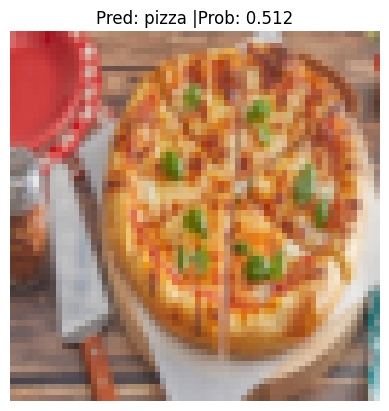

In [147]:
#Pred on our custome image
pred_and_plot_image(model=model_1,
                    image_path=custome_image_path,
                    class_names=class_names,
                    transform=custom_image_transform,
                    device=device)